**Challenge: Real-Time Weather Logger (API + CSV)**

****Build a Python CLI tool that fetches real-time weather data for a given city and logs it to a CSV file for daily tracking.****

Your program should:
1. Ask the user for a city name.
2. Fetch weather data using the OpenWeatherMap API.
3. Store the following in a CSV file (`weather_log.csv`):
   - Date (auto-filled as today's date)
   - City
   - Temperature (in °C)
   - Weather condition (e.g., Clear, Rain)
4. Prevent duplicate entries for the same city on the same day.
5. Allow users to:
   - Add new weather log
   - View all logs
   - Show average, highest, lowest temperatures, and most frequent condition

Bonus:
- Format the output like a table
- Handle API failures and invalid city names gracefully

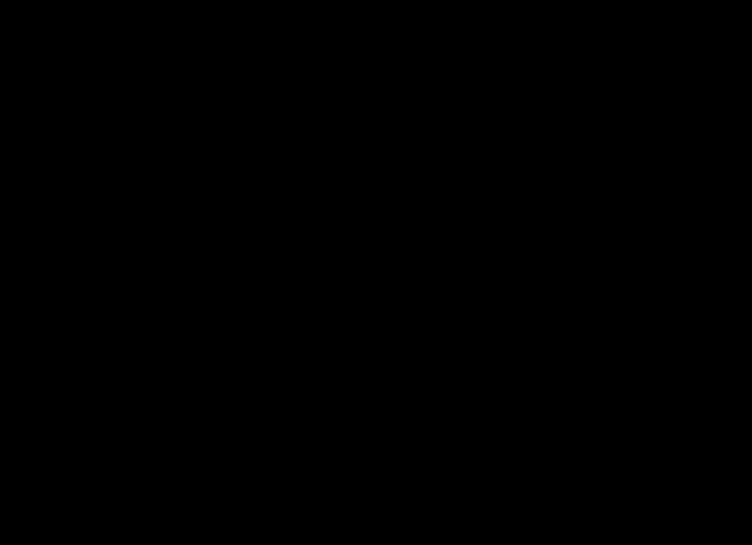

In [6]:
import requests
import csv
import os
from datetime import datetime
from collections import Counter

API_KEY = "ef61715e9a152949762e6906b2addb90"  # Replace with your OpenWeatherMap API key
FILE_NAME = "weather_log.csv"

# ---------------- FETCH WEATHER ----------------
def fetch_weather(city):
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

    try:
        response = requests.get(url)
        data = response.json()

        if response.status_code != 200:
            print("Error: Invalid city or API issue!")
            return None

        temp = data["main"]["temp"]
        condition = data["weather"][0]["main"]

        return temp, condition

    except Exception as e:
        print("Error fetching data:", e)
        return None

# ---------------- CHECK DUPLICATE ----------------
def is_duplicate(date, city):
    if not os.path.exists(FILE_NAME):
        return False

    with open(FILE_NAME, "r") as file:
        reader = csv.reader(file)
        next(reader, None)  # skip header

        for row in reader:
            if row[0] == date and row[1].lower() == city.lower():
                return True

    return False


# ---------------- ADD LOG ----------------
def add_log():
    city = input("Enter city: ").strip()
    today = datetime.now().strftime("%Y-%m-%d")

    if is_duplicate(today, city):
        print("Entry already exists for today!")
        return

    weather = fetch_weather(city)
    if weather is None:
        return

    temp, condition = weather

    file_exists = os.path.exists(FILE_NAME)

    with open(FILE_NAME, "a", newline="") as file:
        writer = csv.writer(file)

        if not file_exists:
            writer.writerow(["Date", "City", "Temperature", "Condition"])

        writer.writerow([today, city, temp, condition])

    print("Weather logged successfully!")


# ---------------- VIEW LOGS ----------------
def view_logs():
    if not os.path.exists(FILE_NAME):
        print("No data found!")
        return

    print("\n{:<12} {:<15} {:<12} {:<15}".format("Date", "City", "Temp (°C)", "Condition"))
    print("-" * 55)

    with open(FILE_NAME, "r") as file:
        reader = csv.reader(file)
        next(reader)

        for row in reader:
            print("{:<12} {:<15} {:<12} {:<15}".format(*row))


# ---------------- STATS ----------------
def show_stats():
    if not os.path.exists(FILE_NAME):
        print("No data to analyze!")
        return

    temps = []
    conditions = []

    with open(FILE_NAME, "r") as file:
        reader = csv.reader(file)
        next(reader)

        for row in reader:
            temps.append(float(row[2]))
            conditions.append(row[3])

    avg_temp = sum(temps) / len(temps)
    max_temp = max(temps)
    min_temp = min(temps)
    most_common = Counter(conditions).most_common(1)[0][0]

    print("\n--- Weather Stats ---")
    print(f"Average Temp: {avg_temp:.2f}°C")
    print(f"Highest Temp: {max_temp}°C")
    print(f"Lowest Temp: {min_temp}°C")
    print(f"Most Frequent Condition: {most_common}")


# ---------------- MENU ----------------
def menu():
    while True:
        print("\n==== Weather Logger ====")
        print("1. Add Weather Log")
        print("2. View Logs")
        print("3. Show Stats")
        print("4. Exit")

        choice = input("Enter choice: ")

        if choice == "1":
            add_log()
        elif choice == "2":
            view_logs()
        elif choice == "3":
            show_stats()
        elif choice == "4":
            print("Goodbye!")
            break
        else:
            print("Invalid choice!")


# ---------------- RUN ----------------
menu()


==== Weather Logger ====
1. Add Weather Log
2. View Logs
3. Show Stats
4. Exit
Error: Invalid city or API issue!

==== Weather Logger ====
1. Add Weather Log
2. View Logs
3. Show Stats
4. Exit
No data found!

==== Weather Logger ====
1. Add Weather Log
2. View Logs
3. Show Stats
4. Exit
Goodbye!
